# Exploratory Data Analysis (EDA) - Overall Weather Patterns
**Project:** Historical Weather India (2000-2024)


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Construct path to file created on Day 4
file_path = "../data/processed/weather_analysis_ready.csv"

# Load the analysis ready dataset with explicit date parsing
df = pd.read_csv(file_path, parse_dates=["date"])

# Display basic structural stats
print(f"Dataframe Shape: {df.shape}")
print("\n=== DATAFRAME STRUCTURAL INFO ===")
print(df.info())

Dataframe Shape: (91320, 21)

=== DATAFRAME STRUCTURAL INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 91320 entries, 0 to 91319
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   city                         91320 non-null  str           
 1   date                         91320 non-null  datetime64[us]
 2   temperature_2m_max           91320 non-null  float64       
 3   temperature_2m_min           91320 non-null  float64       
 4   apparent_temperature_max     91320 non-null  float64       
 5   apparent_temperature_min     91320 non-null  float64       
 6   precipitation_sum            91320 non-null  float64       
 7   rain_sum                     91320 non-null  float64       
 8   weather_code                 91320 non-null  int64         
 9   wind_speed_10m_max           91320 non-null  float64       
 10  wind_gusts_10m_max           91320 non-null  float64 

In [3]:
print("=== FIRST FIVE ROWS ===")
print(df.head())

=== FIRST FIVE ROWS ===
    city       date  temperature_2m_max  temperature_2m_min  \
0  Delhi 2000-01-01                19.9                 7.4   
1  Delhi 2000-01-02                20.0                 5.5   
2  Delhi 2000-01-03                20.1                 6.3   
3  Delhi 2000-01-04                19.8                 6.4   
4  Delhi 2000-01-05                19.4                 5.3   

   apparent_temperature_max  apparent_temperature_min  precipitation_sum  \
0                      19.2                       5.8                0.0   
1                      18.9                       3.4                0.0   
2                      18.2                       4.3                0.0   
3                      18.5                       4.2                0.0   
4                      17.7                       3.2                0.0   

   rain_sum  weather_code  wind_speed_10m_max  ...  \
0       0.0             0                10.9  ...   
1       0.0             3       

In [4]:
# Calculate core baseline project KPIs
total_records = len(df)
total_cities = df["city"].nunique()
start_date = df["date"].min().strftime('%Y-%m-%d')
end_date = df["date"].max().strftime('%Y-%m-%d')
years_covered = df["year"].nunique()

print("=== CORE METADATA METRICS ===")
print("Total Records:", total_records)
print("Total Cities:", total_cities)
print("Start Date:", start_date)
print("End Date:", end_date)
print("Years Covered:", years_covered)

# Calculate meteorological baseline metrics
avg_temp = df["avg_temperature"].mean()
highest_temp = df["temperature_2m_max"].max()
lowest_temp = df["temperature_2m_min"].min()
total_rainfall = df["rain_sum"].sum()
avg_max_wind = df["wind_speed_10m_max"].mean()

print("\n=== METEOROLOGICAL METRICS ===")
print(f"Average Temperature: {avg_temp:.2f}°C")
print(f"Highest Temperature: {highest_temp:.2f}°C")
print(f"Lowest Temperature:  {lowest_temp:.2f}°C")
print(f"Total Combined Rainfall: {total_rainfall:,.2f} mm")
print(f"Average Maximum Wind Speed: {avg_max_wind:.2f} km/h")

=== CORE METADATA METRICS ===
Total Records: 91320
Total Cities: 10
Start Date: 2000-01-01
End Date: 2024-12-31
Years Covered: 25

=== METEOROLOGICAL METRICS ===
Average Temperature: 26.02°C
Highest Temperature: 46.40°C
Lowest Temperature:  1.70°C
Total Combined Rainfall: 282,430.00 mm
Average Maximum Wind Speed: 15.52 km/h


=== THERMAL RANGE DISTRIBUTION SUMMARY ===
       temperature_2m_max  temperature_2m_min  avg_temperature  \
count        91320.000000        91320.000000     91320.000000   
mean            30.900903           21.129450        26.015177   
std              4.770039            5.291931         4.639577   
min             12.300000            1.700000         7.650000   
25%             27.800000           18.000000        23.350000   
50%             30.700000           22.100000        26.450000   
75%             33.800000           25.300000        29.100000   
max             46.400000           34.400000        39.650000   

       temperature_range  
count       91320.000000  
mean            9.771453  
std             3.925928  
min             0.400000  
25%             6.600000  
50%             9.800000  
75%            13.000000  
max            20.800000  


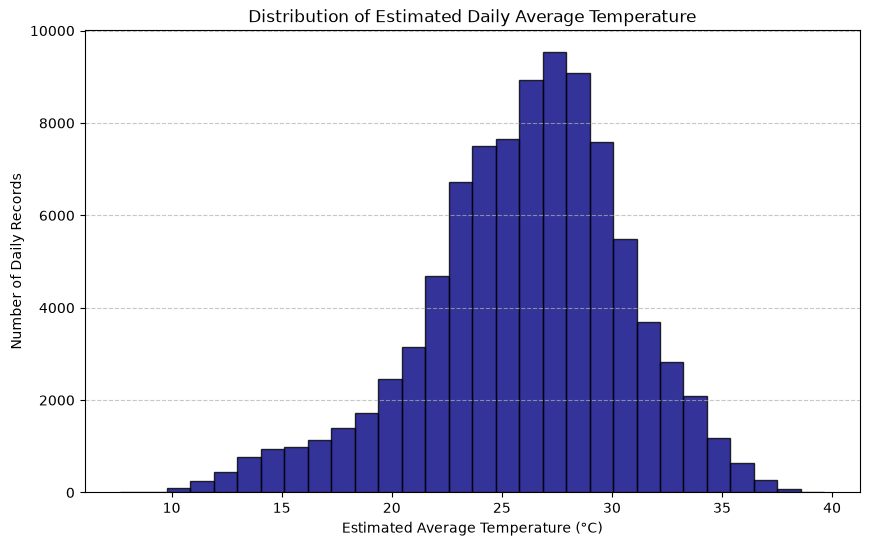

In [5]:
# Inspect raw metric statistics
print("=== THERMAL RANGE DISTRIBUTION SUMMARY ===")
print(df[["temperature_2m_max", "temperature_2m_min", "avg_temperature", "temperature_range"]].describe())

# Render Histogram Chart
plt.figure(figsize=(10, 6))
plt.hist(df["avg_temperature"], bins=30, color="navy", edgecolor="black", alpha=0.8)
plt.xlabel("Estimated Average Temperature (°C)")
plt.ylabel("Number of Daily Records")
plt.title("Distribution of Estimated Daily Average Temperature")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

=== YEARLY TEMPERATURE DATA PREVIEW ===
   year  avg_temperature  avg_max_temperature  avg_min_temperature
0  2000        25.692049            30.725137            20.658962
1  2001        25.781849            30.748329            20.815370
2  2002        26.252452            31.334548            21.170356
3  2003        25.880055            30.821260            20.938849
4  2004        25.907869            30.899016            20.916721


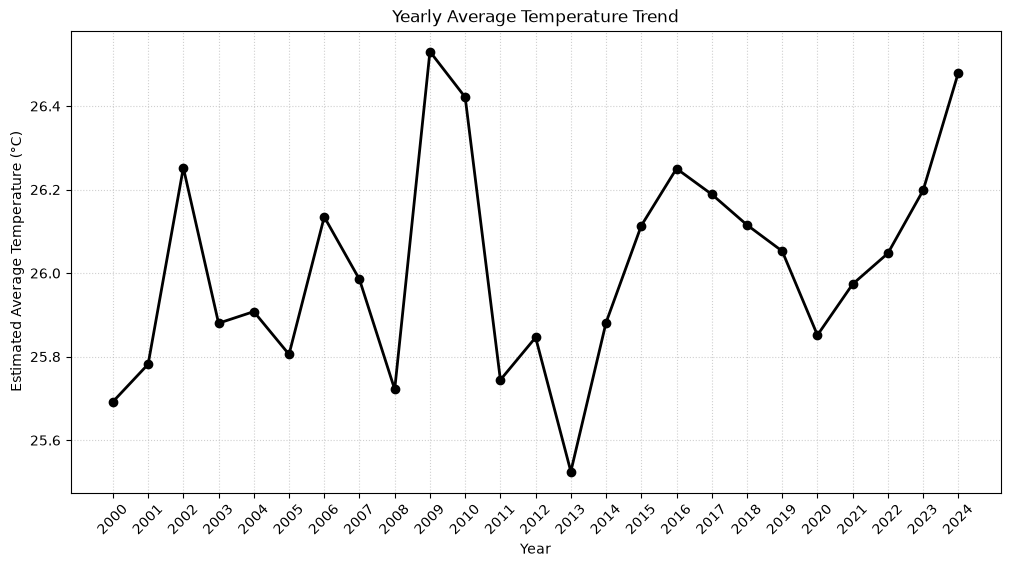

In [6]:
# Aggregate daily records by chronological year
yearly_temperature = df.groupby("year", as_index=False).agg(
    avg_temperature=("avg_temperature", "mean"),
    avg_max_temperature=("temperature_2m_max", "mean"),
    avg_min_temperature=("temperature_2m_min", "mean")
)

print("=== YEARLY TEMPERATURE DATA PREVIEW ===")
print(yearly_temperature.head())

# Render Yearly Timeline Graph
plt.figure(figsize=(12, 6))
plt.plot(yearly_temperature["year"], yearly_temperature["avg_temperature"], marker="o", color="black", linewidth=2)
plt.xlabel("Year")
plt.ylabel("Estimated Average Temperature (°C)")
plt.title("Yearly Average Temperature Trend")
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(yearly_temperature["year"], rotation=45)
plt.show()

In [7]:
# Pinpoint localized annual records
hottest_year_row = yearly_temperature.loc[yearly_temperature["avg_temperature"].idxmax()]
coolest_year_row = yearly_temperature.loc[yearly_temperature["avg_temperature"].idxmin()]

print("=== HIGHEST YEARLY MEAN REGISTRATION ===")
print(hottest_year_row)

print("\n=== LOWEST YEARLY MEAN REGISTRATION ===")
print(coolest_year_row)

=== HIGHEST YEARLY MEAN REGISTRATION ===
year                   2009.000000
avg_temperature          26.530452
avg_max_temperature      31.586411
avg_min_temperature      21.474493
Name: 9, dtype: float64

=== LOWEST YEARLY MEAN REGISTRATION ===
year                   2013.000000
avg_temperature          25.524890
avg_max_temperature      30.243123
avg_min_temperature      20.806658
Name: 13, dtype: float64


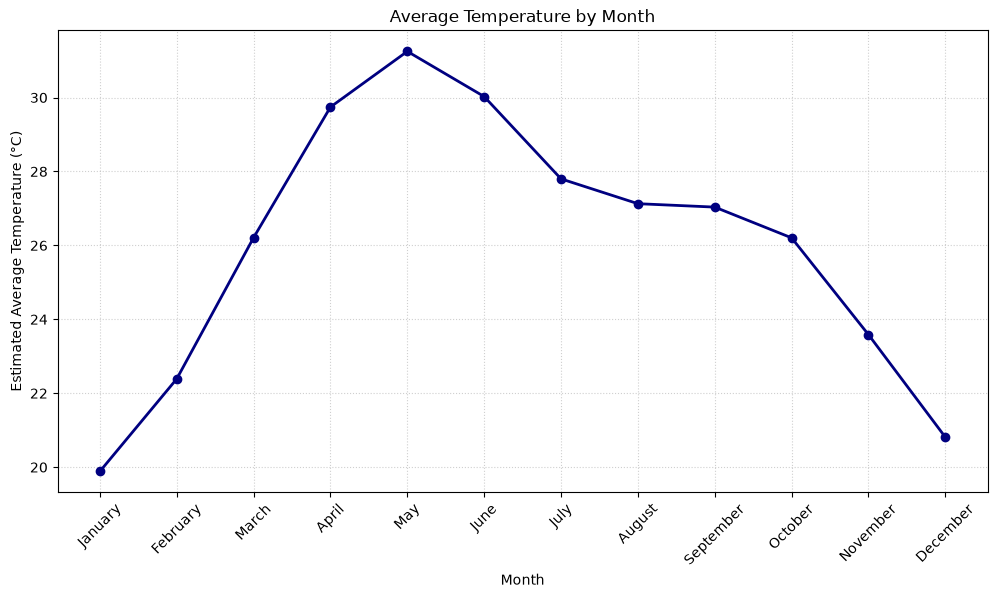

=== HOTTEST MONTH PROFILE ===
month                      5
month_name               May
avg_temperature    31.249226
Name: 4, dtype: object

=== COLDEST MONTH PROFILE ===
month                      1
month_name           January
avg_temperature    19.885594
Name: 0, dtype: object


In [8]:
# Compute tracking matrices by month sequence
monthly_temperature = df.groupby(["month", "month_name"], as_index=False)["avg_temperature"].mean().sort_values("month")

# Render Monthly Trend Graph
plt.figure(figsize=(12, 6))
plt.plot(monthly_temperature["month_name"], monthly_temperature["avg_temperature"], marker="o", color="navy", linewidth=2)
plt.xlabel("Month")
plt.ylabel("Estimated Average Temperature (°C)")
plt.title("Average Temperature by Month")
plt.xticks(rotation=45)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Pinpoint high/low month profiles
print("=== HOTTEST MONTH PROFILE ===")
print(monthly_temperature.loc[monthly_temperature["avg_temperature"].idxmax()])
print("\n=== COLDEST MONTH PROFILE ===")
print(monthly_temperature.loc[monthly_temperature["avg_temperature"].idxmin()])

In [9]:
# Profile observations aggregated across regional seasons
seasonal_analysis = df.groupby("season", as_index=False).agg(
    avg_temperature=("avg_temperature", "mean"),
    total_rainfall=("rain_sum", "sum"),
    avg_wind_speed=("wind_speed_10m_max", "mean")
)

print("=== SEASONAL SUMMARY DATA ===")
print(seasonal_analysis)

=== SEASONAL SUMMARY DATA ===
         season  avg_temperature  total_rainfall  avg_wind_speed
0       Monsoon        27.988948        221277.3       17.669970
1  Post-Monsoon        24.915859         32651.6       12.513784
2        Summer        29.060339         18202.1       16.755652
3        Winter        20.987523         10299.0       13.402025


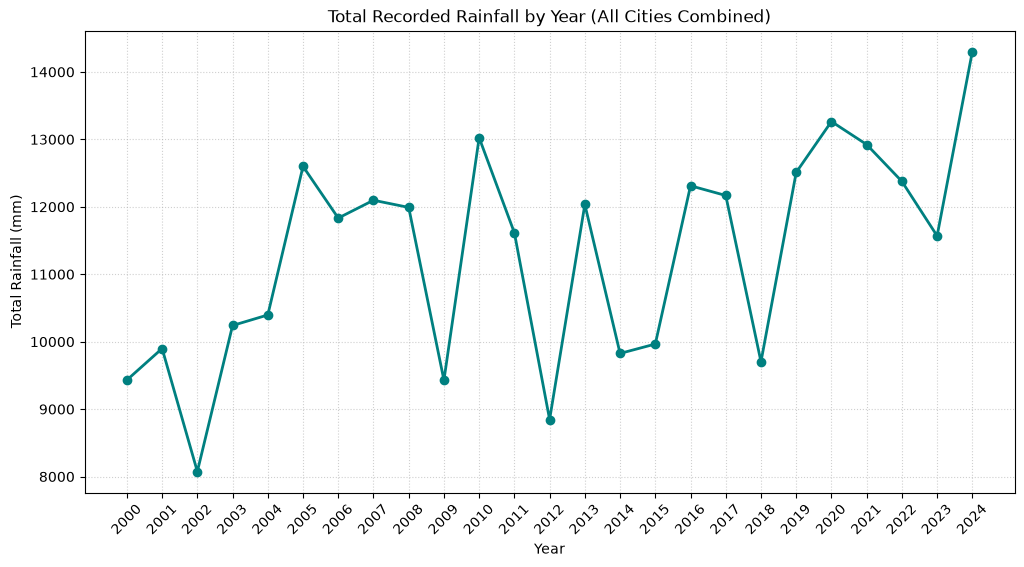

In [10]:
# Compute combined annual tracking metrics
yearly_rainfall = df.groupby("year", as_index=False)["rain_sum"].sum()

# Render Annual Total Trend Chart
plt.figure(figsize=(12, 6))
plt.plot(yearly_rainfall["year"], yearly_rainfall["rain_sum"], marker="o", color="teal", linewidth=2)
plt.xlabel("Year")
plt.ylabel("Total Rainfall (mm)")
plt.title("Total Recorded Rainfall by Year (All Cities Combined)")
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(yearly_rainfall["year"], rotation=45)
plt.show()

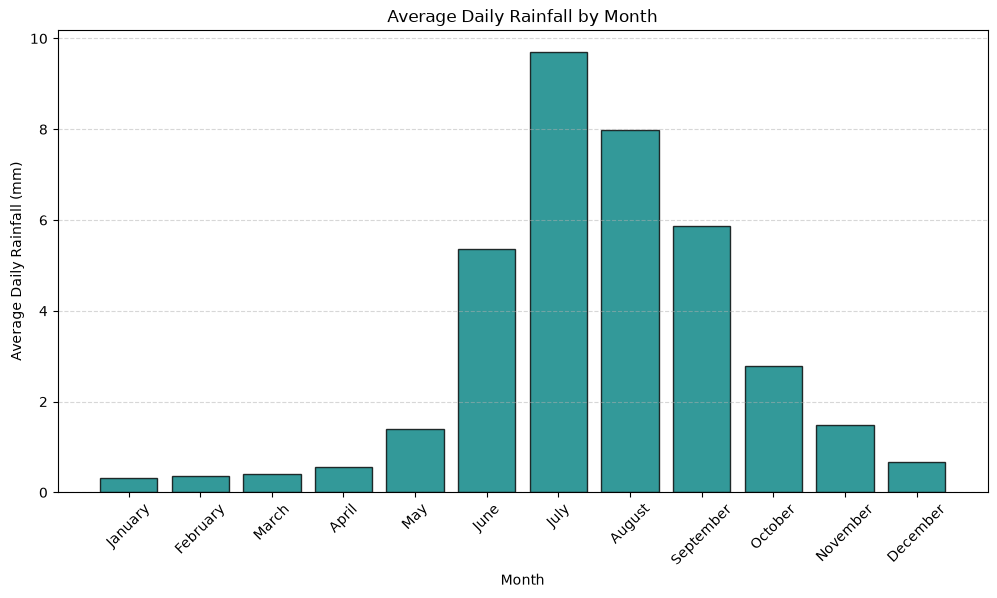

In [11]:
# Compute historical monthly rainfall benchmarks
monthly_rainfall = df.groupby(["month", "month_name"], as_index=False)["rain_sum"].mean().sort_values("month")

# Render Monthly Average Distribution Bars
plt.figure(figsize=(12, 6))
plt.bar(monthly_rainfall["month_name"], monthly_rainfall["rain_sum"], color="teal", edgecolor="black", alpha=0.8)
plt.xlabel("Month")
plt.ylabel("Average Daily Rainfall (mm)")
plt.title("Average Daily Rainfall by Month")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [12]:
# Compute regional aggregations per city boundary
city_summary = df.groupby("city", as_index=False).agg(
    avg_temperature=("avg_temperature", "mean"),
    avg_daily_rainfall=("rain_sum", "mean"),
    total_recorded_rainfall=("rain_sum", "sum"),
    avg_wind_speed=("wind_speed_10m_max", "mean"),
    rainy_days=("rainy_day", "sum")
)

# Render results sorted by highest mean temperatures
print("=== CITY WEATHER HIGHLIGHTS TABLE ===")
print(city_summary.sort_values("avg_temperature", ascending=False))

=== CITY WEATHER HIGHLIGHTS TABLE ===
        city  avg_temperature  avg_daily_rainfall  total_recorded_rainfall  \
2    Chennai        28.410113            3.007643                  27465.8   
0  Ahmedabad        27.475405            2.449255                  22366.6   
8     Mumbai        27.051834            5.694284                  52000.2   
6    Kolkata        26.437719            4.551456                  41563.9   
4  Hyderabad        26.310671            2.229895                  20363.4   
9       Pune        25.435699            4.274956                  39038.9   
7    Lucknow        25.362900            2.774693                  25338.5   
5     Jaipur        25.255355            1.473095                  13452.3   
3      Delhi        24.947832            1.851774                  16910.4   
1  Bangalore        23.464241            2.620456                  23930.0   

   avg_wind_speed  rainy_days  
2       18.359450        4843  
0       14.194601        2542  
8      

In [13]:
print("=== MAXIMUM ABSOLUTE AIR TEMPERATURE RECORD ===")
print(df.loc[df["temperature_2m_max"].idxmax(), ["city", "date", "temperature_2m_max"]])

print("\n=== MINIMUM ABSOLUTE AIR TEMPERATURE RECORD ===")
print(df.loc[df["temperature_2m_min"].idxmin(), ["city", "date", "temperature_2m_min"]])

print("\n=== MAXIMUM ABSOLUTE DAILY DOWNPOUR RECORD ===")
print(df.loc[df["rain_sum"].idxmax(), ["city", "date", "rain_sum"]])

print("\n=== MAXIMUM ABSOLUTE WIND GUST VELOCITY RECORD ===")
print(df.loc[df["wind_speed_10m_max"].idxmax(), ["city", "date", "wind_speed_10m_max"]])

=== MAXIMUM ABSOLUTE AIR TEMPERATURE RECORD ===
city                                Delhi
date                  2024-05-28 00:00:00
temperature_2m_max                   46.4
Name: 8914, dtype: object

=== MINIMUM ABSOLUTE AIR TEMPERATURE RECORD ===
city                              Lucknow
date                  2019-12-30 00:00:00
temperature_2m_min                    1.7
Name: 89491, dtype: object

=== MAXIMUM ABSOLUTE DAILY DOWNPOUR RECORD ===
city                  Ahmedabad
date        2017-07-22 00:00:00
rain_sum                  339.9
Name: 61204, dtype: object

=== MAXIMUM ABSOLUTE WIND GUST VELOCITY RECORD ===
city                              Kolkata
date                  2020-05-20 00:00:00
wind_speed_10m_max                   68.9
Name: 25709, dtype: object


In [14]:
# Compile granular combined city-year historical indices
city_year_summary = df.groupby(["city", "year"], as_index=False).agg(
    avg_temperature=("avg_temperature", "mean"),
    avg_max_temperature=("temperature_2m_max", "mean"),
    avg_min_temperature=("temperature_2m_min", "mean"),
    total_rainfall=("rain_sum", "sum"),
    rainy_days=("rainy_day", "sum"),
    avg_wind_speed=("wind_speed_10m_max", "mean")
)

print("=== CITY-YEAR NESTED HISTORICAL PREVIEW ===")
print(city_year_summary.head(10))

=== CITY-YEAR NESTED HISTORICAL PREVIEW ===
        city  year  avg_temperature  avg_max_temperature  avg_min_temperature  \
0  Ahmedabad  2000        27.613115            33.849180            21.377049   
1  Ahmedabad  2001        27.432192            33.331781            21.532603   
2  Ahmedabad  2002        27.900822            34.043562            21.758082   
3  Ahmedabad  2003        27.433151            33.224384            21.641918   
4  Ahmedabad  2004        27.373634            33.231967            21.515301   
5  Ahmedabad  2005        26.535205            32.374521            20.695890   
6  Ahmedabad  2006        27.104521            32.724932            21.484110   
7  Ahmedabad  2007        27.178219            32.795342            21.561096   
8  Ahmedabad  2008        26.767486            32.450000            21.084973   
9  Ahmedabad  2009        27.968630            33.815068            22.122192   

   total_rainfall  rainy_days  avg_wind_speed  
0           373.

In [15]:
# Establish structural target directory context path configurations
output_dir = "../data/processed/aggregated/"
os.makedirs(output_dir, exist_ok=True)

# Export all engineered summary objects to cut down application runtime lag
yearly_temperature.to_csv(os.path.join(output_dir, "yearly_temperature.csv"), index=False)
monthly_temperature.to_csv(os.path.join(output_dir, "monthly_temperature.csv"), index=False)
monthly_rainfall.to_csv(os.path.join(output_dir, "monthly_rainfall.csv"), index=False)
city_summary.to_csv(os.path.join(output_dir, "city_summary.csv"), index=False)
city_year_summary.to_csv(os.path.join(output_dir, "city_year_summary.csv"), index=False)

print(f"Success! All 5 optimized aggregation files saved into: {output_dir}")

Success! All 5 optimized aggregation files saved into: ../data/processed/aggregated/
